In [1]:
from math import *
%matplotlib inline
import statistics
from scipy import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import *
from scipy.stats import *
from scipy.optimize import curve_fit
from scipy.special import gamma
import statistics
from scipy.optimize import curve_fit
from scipy.special import erf

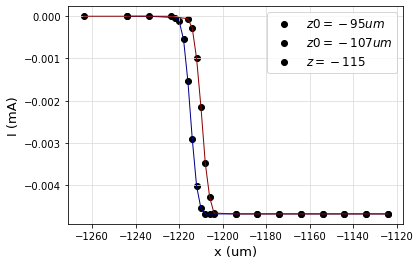

In [2]:
x0 = -1124
y0 = -2245.3
z01 = -107
z02 = -95
z03= -115
I0 = -0.00468
V = -0.3 
f = 1

def knife_edge_fit(x, I0, x0, w):
    return I0 * (1 - 0.5 * erf((np.sqrt(2) * (x - x0)) / w))

x1=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-100,x0-120,x0-140]
I1=[I0,I0,I0,I0,I0,I0,I0,I0,-0.00466,-0.00428,-0.00348,-0.00215,-0.001,-0.00028,-0.00006,0,0,0]

x2=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98,x0-110,x0-120]
I2=[I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,-0.00455,-0.00402,-0.00290,-0.00154,-0.00055,-0.00012,-0.00003,0,0]

x3=[]
I3=[]

plt.figure(figsize=(6,4))

plt.scatter(x2,I2,label='$z0=-95 um$', color = 'black')
plt.plot(x2,I2,color='darkblue',linewidth=1)

plt.scatter(x1,I1,label='$z0=-107 um$', color = 'black')
plt.plot(x1,I1,color='darkred',linewidth=1)

plt.scatter(x3,I3, label='$z=-115$',color='black')
plt.plot(x3,I3,color='yellow')

plt.xlabel('x (um)', fontsize=13)
plt.ylabel('I (mA)', fontsize=13)

plt.legend(fontsize=12)
plt.grid(color = 'gainsboro')


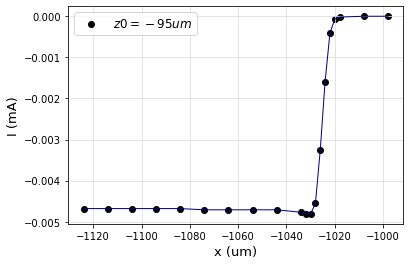

In [3]:
x0 = -1124
y0 = -2245.3
z0 = -73
I0 = -0.00468
V = -0.3 
f = 1

x=[x0, x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+90,x0+92,x0+94,x0+96,x0+98,x0+100,x0+102,x0+104,x0+106,x0+116,x0+126]
I=[I0,I0,I0,I0,I0,-0.00471,-0.00471,-0.00471,-0.00471,-0.00477,-0.00480,-0.00481,-0.00455,-0.00325,-0.00159,-0.00041,-0.00007,-0.00002,0,0]


plt.figure(figsize=(6,4))
plt.scatter(x,I,label='$z0=-95 um$', color = 'black')
plt.plot(x,I,color='darkblue',linewidth=1)

plt.xlabel('x (um)', fontsize=13)
plt.ylabel('I (mA)', fontsize=13)

plt.legend(fontsize=12)
plt.grid(color = 'gainsboro')



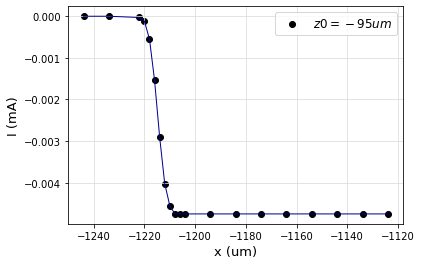

In [4]:
x0 = -1124
y0 = -2245.3
z0 = -95
I0 = -0.00475
V = -0.3 
f = 1

x2=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98,x0-110,x0-120]
I2=[I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,-0.00455,-0.00402,-0.00290,-0.00154,-0.00055,-0.00012,-0.00003,0,0]

plt.figure(figsize=(6,4))
plt.scatter(x2,I2,label='$z0=-95 um$', color = 'black')
plt.plot(x2,I2,color='darkblue',linewidth=1)

plt.xlabel('x (um)', fontsize=13)
plt.ylabel('I (mA)', fontsize=13)

plt.legend(fontsize=12)
plt.grid(color = 'gainsboro')



In [5]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf, erfinv
import matplotlib.pyplot as plt

In [21]:
def eror_funkcija(x, x0, sigma, A, C):
    return A * 0.5 * (1 + erf((x - x0) / (np.sqrt(2) * sigma))) + C

def spot_size_function(x, I):
    I=np.array(I)
    if np.mean(I) < 0:
        I = -I
    I = I - np.min(I)
    I = (I - np.min(I)) / (np.max(I) - np.min(I))
    
    popt, pcov = curve_fit(eror_funkcija, x, I, p0=[np.mean(x), 1, 1, 0], maxfev=5000)
    x0, sigma, A, C = popt
    
    perr = np.sqrt(np.diag(pcov))
    sigma_error = perr[1]
    
    # Računanje točaka za 16% i 84% intenziteta,tu umjesto -0.68 i 0.68 staviš druge brojeve za druge postotke ako želiš 80/20 ili 90/10 itd
    donja_granica = x0 + np.sqrt(2) * sigma * erfinv(-0.68)
    gornja_granica = x0 + np.sqrt(2) * sigma * erfinv(0.68)
    
    # Promjer snopa
    spot_size = abs(donja_granica - gornja_granica)
    relative_error = 2 * sigma_error / spot_size
    
    # Prikaz rezultata
    plt.figure(figsize=(7, 5))
    plt.plot(x, I, 'o', label="Izmjerene vrijednosti", color='black')
    fit_curve = eror_funkcija(x, *popt)
    plt.plot(x, fit_curve, '-', label="fit", color='red')
    plt.axvline(x=donja_granica, color='gray', linestyle='--', label=f'16% intenziteta ')
    plt.axvline(x=gornja_granica, color='black', linestyle='--', label=f'84% intenziteta')
    #plt.title("Knife Edge Method")
    plt.xlabel("x [µm]")
    plt.ylabel("Intenzitet [a.u.]")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return spot_size, relative_error

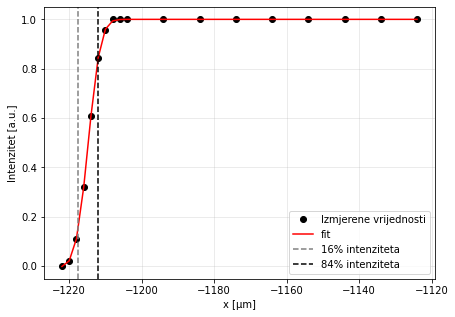

Spot size za z=-95: 5.38 ± 0.01 um


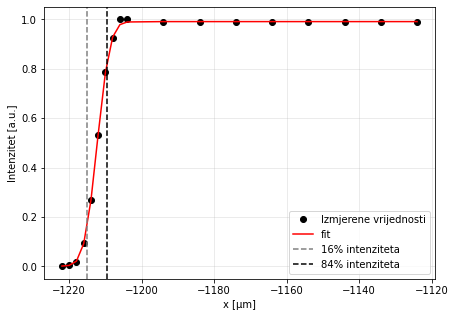

Spot size za z=-99: 5.56 ± 0.02 um


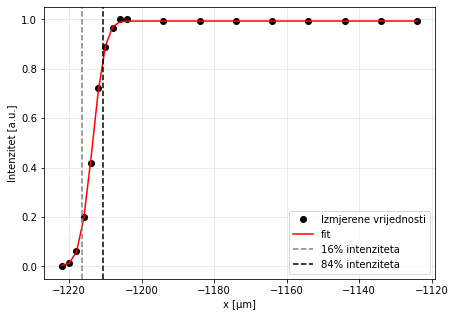

Spot size za z=-103: 5.57 ± 0.02 um


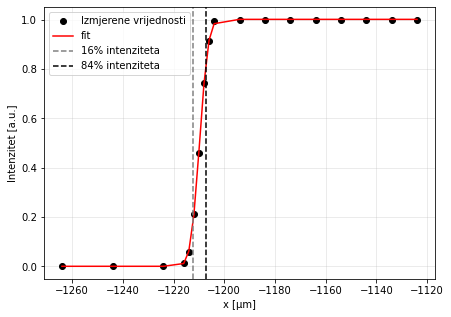

Spot size za z=-107: 5.44 ± 0.01 um


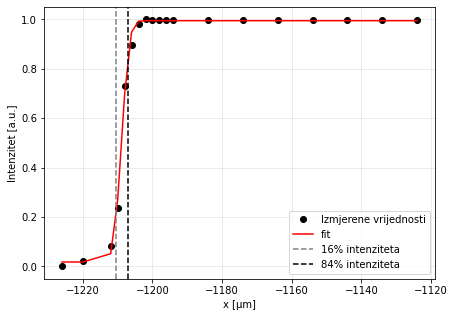

Spot size za z=-111: 3.42 ± 0.07 um


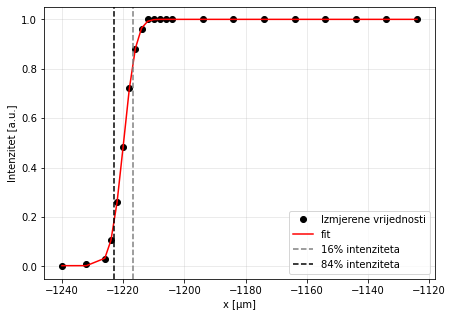

Spot size za z=-115: 6.48 ± 0.01 um


In [22]:
#20.3.2025. 
x0 = -1124
y0 = -2245.3
z1 = -95
z2 = -99
z3 = -103
z4 = -107
z5 = -111
z6 = -115
I0_z1 = -0.00475
I0_z2 = -0.00474
I0_z3 = -0.00473
I0_z4 = -0.00468
I0_z5 = -0.00469
I0_z6 = -0.00471
V = -0.3 
f = 1

x_z1=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98]
I_z1=[I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,-0.00455,-0.00402,-0.0029,-0.00154,-0.00055,-0.00012,-0.00003]

x_z2=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98]
I_z2=[I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,-0.00480,-0.00480,-0.00444,-0.00377,-0.00255,-0.00130,-0.00045,-0.00009,-0.00003,0]

x_z3=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98]
I_z3=[I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,-0.00477,-0.00477,-0.00460,-0.00424,-0.00344,-0.002,-0.00096,-0.0003,-0.00006,0]

x_z4=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-100,x0-120,x0-140]
I_z4=[I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,-0.00466,-0.00428,-0.00348,-0.00215,-0.001,-0.00028,-0.00006,0,0,0]

x_z5=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-72,x0-74,x0-76,x0-78,x0-80,x0-82,x0-84,x0-86,x0-88,x0-96,x0-102]
I_z5=[I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,I0_z5,-0.00470,-0.00461,-0.00422,-0.00344,-0.00112,-0.00038,-0.0001,0]

x_z6=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98,x0-100,x0-102,x0-108,x0-116]
I_z6=[I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,-0.00453, -0.00415,-0.00340,-0.00228,-0.00123,-0.0005,-0.00014,-0.00004,0]

spot_size = spot_size_function(x_z1, I_z1)
print(f"Spot size za z=-95: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z2, I_z2)
print(f"Spot size za z=-99: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z3, I_z3)
print(f"Spot size za z=-103: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z4, I_z4)
print(f"Spot size za z=-107: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z5, I_z5)
print(f"Spot size za z=-111: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z6, I_z6)
print(f"Spot size za z=-115: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

<ErrorbarContainer object of 3 artists>

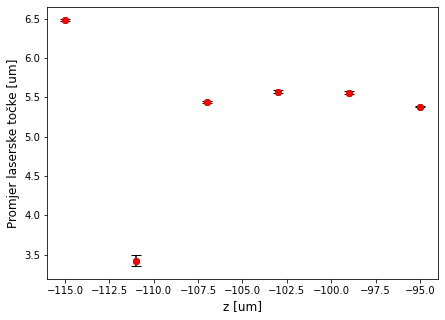

In [33]:
z=[-95,-99,-103, -107, -111, -115]

s=[5.38,5.56,5.57,5.44, 3.42, 6.48]

se=[0.01,0.02,0.02, 0.01, 0.07, 0.01]


#ax.errorbar(x, y, xerr=0, yerr=ye)
plt.figure(figsize=(7, 5))
plt.scatter(z, s, color='black')
plt.xlabel("z [um]", fontsize=12)
plt.ylabel("Promjer laserske točke [um]", fontsize=12)

y_error =[se, se] 
plt.errorbar(z, s,yerr = y_error, fmt ='o', ecolor='black',capsize=5,color='r')

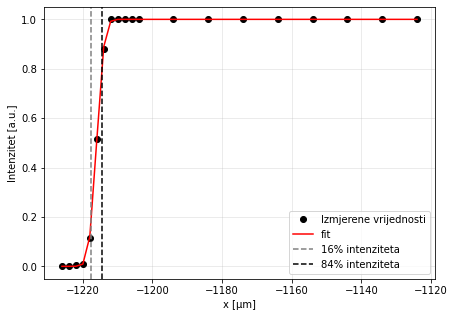

Lijevi rub diode: 3.32 ± 0.01 um


<Figure size 432x288 with 0 Axes>

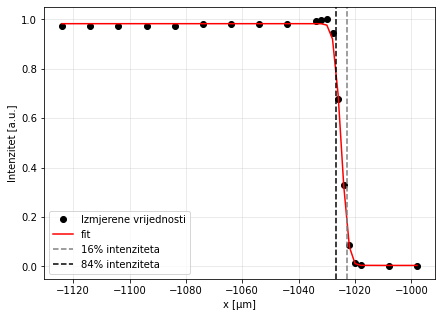

Desni rub diode: 4.03 ± 0.04 um


<Figure size 432x288 with 0 Axes>

In [23]:
#20.3.2025. PROVJERA SIMETRIČNOSTI POSTAVA - LIJEVI I DESNI RUB DIODE
x0 = -1124
y0 = -2245.3
z0 = -73
I0 = -0.00468
V = -0.3 
f = 1

x_L=[x0, x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98,x0-100,x0-102]
I_L=[I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,-0.00412,-0.00242,-0.00053,-0.00005,-0.00002,0,0]

x_D=[x0, x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+90,x0+92,x0+94,x0+96,x0+98,x0+100,x0+102,x0+104,x0+106,x0+116,x0+126]
I_D=[I0,I0,I0,I0,I0,-0.00471,-0.00471,-0.00471,-0.00471,-0.00477,-0.00480,-0.00481,-0.00455,-0.00325,-0.00159,-0.00041,-0.00007,-0.00002,0,0]

spot_size = spot_size_function(x_L, I_L)
print(f"Lijevi rub diode: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")
plt.savefig("graf_lijevi_rub")

spot_size = spot_size_function(x_D, I_D)
print(f"Desni rub diode: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")
plt.savefig("graf_desni_rub")

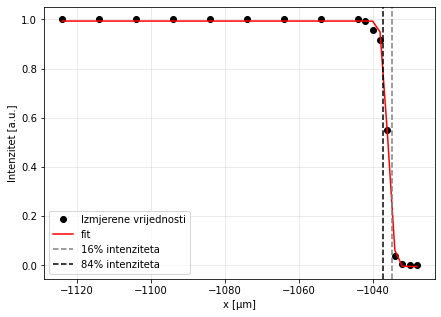

Gornji rub diode: 2.48 ± 0.07 um


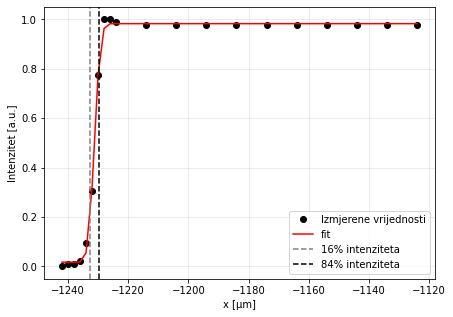

Donji rub diode: 3.12 ± 0.05 um


In [137]:
#20.3.2025. PROVJERA SIMETRIČNOSTI POSTAVA - GORNJI I DONJI RUB DIODE
x0 = -1124
y0 = -2245.3
z0 = -73
I0 = -0.00464
V = -0.3 
f = 1

x_G=[x0, x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+82,x0+84,x0+86,x0+88,x0+90,x0+92,x0+94,x0+96]
I_G=[I0,I0,I0,I0,I0,I0,I0,I0,I0,-0.00460,-0.00444,-0.00425,-0.00255,-0.00017,-0.00003,0,0]

x_D=[x0, x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-90,x0-100,x0-102,x0-104,x0-106,x0-108,x0-110,x0-112,x0-114,x0-116,x0-118]
I_D=[I0,I0,I0,I0,I0,I0,I0,I0,I0,I0,-0.00470,-0.00475,-0.00475,-0.00368,-0.00145,-0.00046,-0.0001,-0.00005,-0.00004,0]

spot_size = spot_size_function(x_G, I_G)
print(f"Gornji rub diode: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_D, I_D)
print(f"Donji rub diode: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")


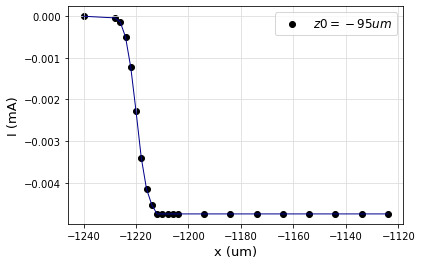

In [25]:
x0 = -1124
y0 = -2245.3
z0 = -95
I0_z6 = -0.00475
V = -0.3 
f = 1

x_z6=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-70,x0-80,x0-82,x0-84,x0-86,x0-88,x0-90,x0-92,x0-94,x0-96,x0-98,x0-100,x0-102,x0-104,x0-116]
I_z6=[I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,I0_z6,-0.00453, -0.00415,-0.00340,-0.00228,-0.00123,-0.0005,-0.00014,-0.00004,0]
plt.figure(figsize=(6,4))
plt.scatter(x_z6,I_z6,label='$z0=-95 um$', color = 'black')
plt.plot(x_z6,I_z6,color='darkblue',linewidth=1)

plt.xlabel('x (um)', fontsize=13)
plt.ylabel('I (mA)', fontsize=13)

plt.legend(fontsize=12)
plt.grid(color = 'gainsboro')

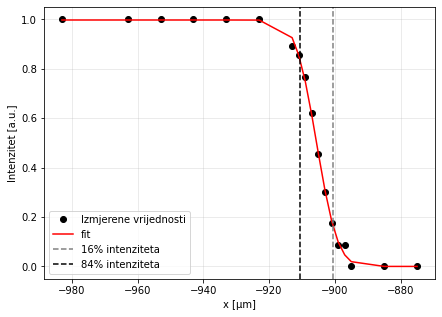

Spot size za z=-280.8: 10.14 ± 0.04 um


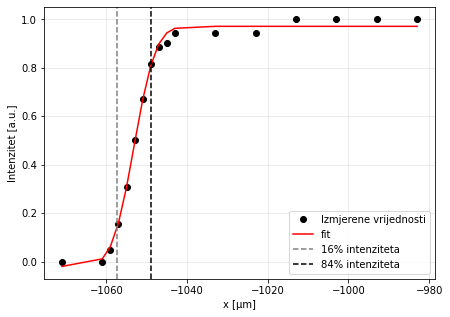

Spot size za z=--270.8: 8.42 ± 0.06 um


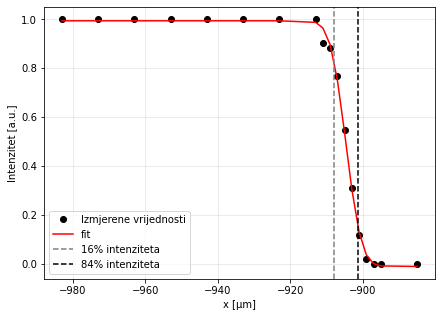

Spot size za z=-260.8: 6.69 ± 0.05 um


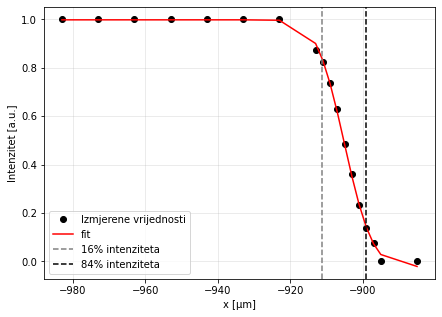

 12.09 ± 0.03 um


In [138]:
#20.3.2025. 
x0 = -983
y0 = -2745
z1 = -280.8
z2 = -270.8
z3 = -260.8
z4 = -290.8

I0_z1 = -0.00103
I0_z2 = -0.00104
I0_z3 = -0.00104
I0_z4 = -0.00103
V = -0.3 
f = 2

x_z1=[x0,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+72,x0+74,x0+76,x0+78,x0+80,x0+82,x0+84,x0+86,x0+88,x0+98,x0+108]
I_z1=[I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,-0.00092,-0.00088,-0.00079,-0.00064,-0.00047,-0.00031,-0.00018,-0.00009,-0.00009,0,0,0]

x_z2=[x0,x0-10,x0-20,x0-30,x0-40,x0-50,x0-60,x0-62,x0-64,x0-66,x0-68,x0-70,x0-72,x0-74,x0-76,x0-78,x0-88]
I_z2=[I0_z2,I0_z2,I0_z2,I0_z2,-0.00098,-0.00098,-0.00098,-0.00094,-0.00092,-0.00085,-0.0007,-0.00052,-0.00032,-0.00016,-0.00005,0,0]

x_z3=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+72,x0+74,x0+76,x0+78,x0+80,x0+82,x0+84,x0+86,x0+88,x0+98]
I_z3=[I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,-0.00094,-0.00092,-0.0008,-0.00057,-0.00032,-0.00012,-0.00002,-0.000,-0.0000,0]

x_z4=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+72,x0+74,x0+76,x0+78,x0+80,x0+82,x0+84,x0+86,x0+88,x0+98]
I_z4=[I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,-0.0009,-0.00085,-0.00076,-0.00065,-0.0005,-0.00037,-0.00024,-0.00014,-0.00008,0,0]


spot_size = spot_size_function(x_z1, I_z1)
print(f"Spot size za z=-280.8: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z2, I_z2)
print(f"Spot size za z=--270.8: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z3, I_z3)
print(f"Spot size za z=-260.8: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z4, I_z4)
print(f" {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

<ErrorbarContainer object of 3 artists>

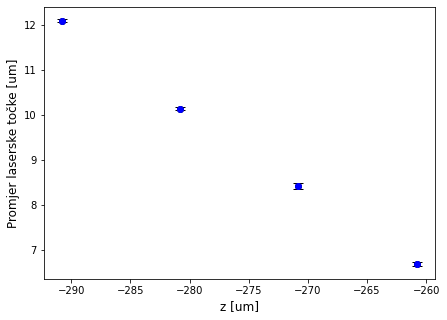

In [57]:
z=[-280.8,-270.8,-260.8, -290.8]

s=[10.14,8.42, 6.69, 12.09]

se=[0.04,0.06,0.05, 0.03]


#ax.errorbar(x, y, xerr=0, yerr=ye)
plt.figure(figsize=(7, 5))
plt.scatter(z, s, color='black')
plt.xlabel("z [um]", fontsize=12)
plt.ylabel("Promjer laserske točke [um]", fontsize=12)

y_error =[se, se] 
plt.errorbar(z, s,yerr = y_error, fmt ='o', ecolor='black',capsize=5,color='blue')

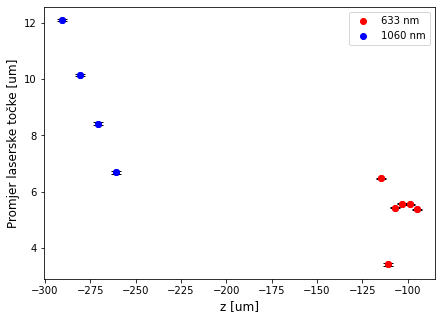

In [85]:
z2=[-280.8,-270.8,-260.8, -290.8]
s2=[10.14,8.42, 6.69, 12.09]
se2=[0.04,0.06,0.05, 0.03]

z1=[-95,-99,-103, -107, -111, -115]
s1=[5.38,5.56,5.57,5.44, 3.42, 6.48]
se1=[0.01,0.02,0.02, 0.01, 0.07, 0.01]


#ax.errorbar(x, y, xerr=0, yerr=ye)
plt.figure(figsize=(7, 5))
plt.scatter(z1, s1, color='red', label = '633 nm')
plt.xlabel("z [um]", fontsize=12)
plt.ylabel("Promjer laserske točke [um]", fontsize=12)

y_error1 =[se1, se1] 
plt.errorbar(z1, s1,yerr = y_error1, fmt ='o', ecolor='black',capsize=5,color='r')

plt.scatter(z2, s2, color='blue', label = '1060 nm')
y_error2 =[se2, se2] 
plt.errorbar(z2, s2,yerr = y_error2, fmt ='o', ecolor='black',capsize=5,color='blue')

plt.legend()
plt.show()

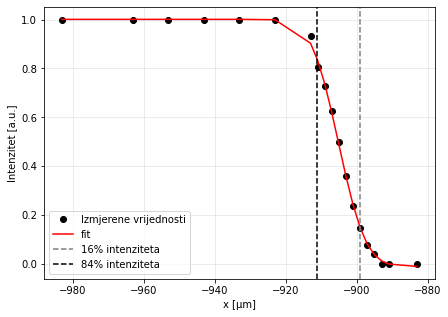

Spot size za z=-290.8: 12.06 ± 0.03 um


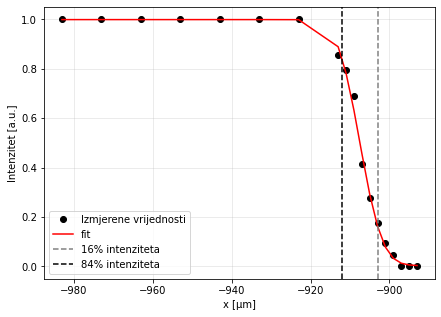

Spot size za z=-285.8: 8.95 ± 0.05 um


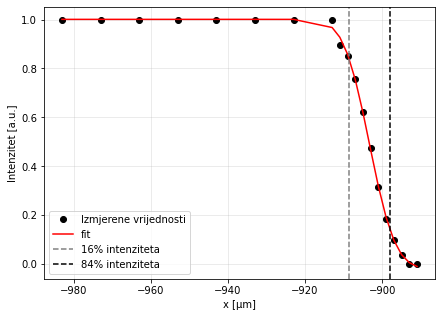

Spot size za z=-280.8: 10.45 ± 0.03 um


In [70]:
#20.3.2025. 
x0 = -983
y0 = -2745
z1 = -290.8
z2 = -285.8
z3 = -280.8


I0_z1 = -0.00189
I0_z2 = -0.00189
I0_z3 = -0.00186

V = -0.3 
f = 10

x_z1=[x0,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+72,x0+74,x0+76,x0+78,x0+80,x0+82,x0+84,x0+86,x0+88,x0+90,x0+92, x0+100]
I_z1=[I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,-0.00176,-0.00152,-0.00138,-0.00118,-0.00094,-0.00068,-0.00045,-0.00028,-0.00015,-0.00008,0,0,0 ]

x_z2=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+72,x0+74,x0+76,x0+78,x0+80,x0+82,x0+84,x0+86,x0+88, x0+90]
I_z2=[I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,-0.00162,-0.0015,-0.0013,-0.00078,-0.00052,-0.00033,-0.00018,-0.00009,0,0,0]

x_z3=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+72,x0+74,x0+76,x0+78,x0+80,x0+82,x0+84,x0+86,x0+88,x0+90,x0+92]
I_z3=[I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,-0.00167,-0.00158,-0.00141,-0.00116,-0.00088,-0.00059,-0.00034,-0.00018,-0.00007,0, 0]

spot_size = spot_size_function(x_z1, I_z1)
print(f"Spot size za z=-290.8: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z2, I_z2)
print(f"Spot size za z=-285.8: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z3, I_z3)
print(f"Spot size za z=-280.8: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")


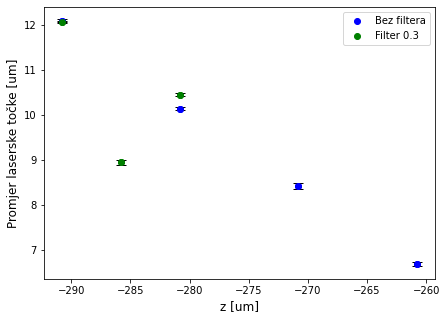

In [142]:
z2=[-290.8,-285.8,-280.8]
s2=[12.06,8.95, 10.45]
se2=[0.03,0.05, 0.03]
z1=[-280.8,-270.8,-260.8, -290.8]
s1=[10.14,8.42, 6.69, 12.09]
se1=[0.04,0.06,0.05, 0.03]

plt.figure(figsize=(7, 5))
plt.scatter(z1, s1, color='blue', label = 'Bez filtera')
y_error1 =[se1, se1] 
plt.errorbar(z1, s1,yerr = y_error1, fmt ='o', ecolor='black',capsize=5,color='blue')

plt.scatter(z2, s2, color='green', label = 'Filter 0.3')
y_error2 =[se2, se2] 
plt.errorbar(z2, s2,yerr = y_error2, fmt ='o', ecolor='black',capsize=5,color='green' )


plt.xlabel("z [um]", fontsize=12)
plt.ylabel("Promjer laserske točke [um]", fontsize=12)

plt.legend()
plt.show()

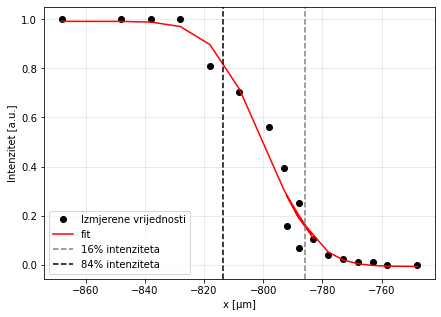

Spot size za z=4642 um: 27.65 ± 0.16 um


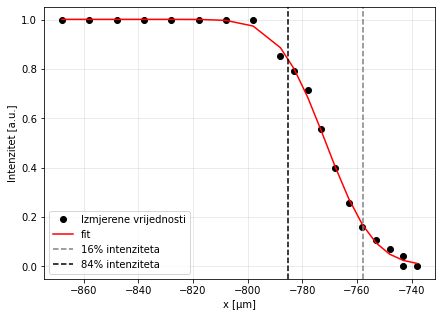

Spot size za z=4642, s filterom 0.3: 27.49 ± 0.04 um


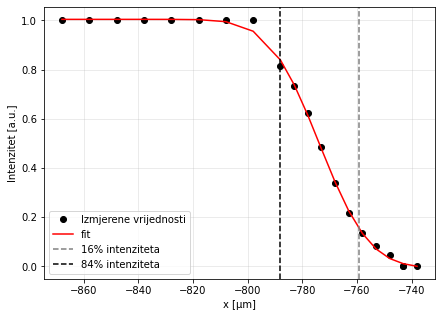

Spot size za z= 4572 um: 28.90 ± 0.03 um


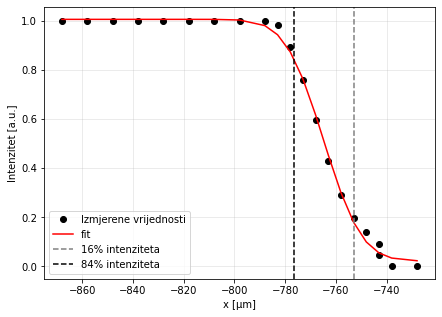

Spot size za z= 4572 um, s filterom 0.3: 23.68 ± 0.05 um


In [119]:
 
x0 = -868
y0 = -2185
z1 = 4642
z2 = 4572
z3 = 4642
z4 = 4572


I0_z1 = -0.00892
I0_z2 = -0.00250
I0_z3 = -0.00738
I0_z4 = -0.00216

V = -0.3 
f = 10

x_z1=[x0,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+75,x0+80,x0+76,x0+85,x0+80,x0+90,x0+95,x0+100,x0+105,x0+110, x0+120]
I_z1=[I0_z1,I0_z1,I0_z1,I0_z1,-0.00722,-0.00627,-0.005,-0.0035,-0.00225,-0.0014,-0.00092,-0.00061,-0.00036,-0.00019,-0.00011,-0.00008,0,0 ]

x_z2=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+85,x0+90,x0+95,x0+100,x0+105,x0+110,x0+115,x0+120, x0+125, x0+125, x0+130]
I_z2=[I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,-0.00213,-0.00198,-0.00179,-0.00139,-0.001,-0.00064,-0.0004,-0.00027,-0.00018,-0.00011,0,0]

x_z3=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+85,x0+90,x0+95,x0+100,x0+105,x0+110,x0+115,x0+120, x0+125, x0+125, x0+130]
I_z3=[I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,I0_z3,-0.00604,-0.00546,-0.00467,-0.00368,-0.00264,-0.00176,-0.00117,-0.00079,-0.00054,-0.00022,-0.0002,-0.0002]

x_z4=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+85,x0+90,x0+95,x0+100,x0+105,x0+110,x0+115,x0+120, x0+125, x0+125, x0+130, x0+140]
I_z4=[I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,I0_z4,-0.00212,-0.00193,-0.00164,-0.00129,-0.00093,-0.00063,-0.00043,-0.0003,-0.0002,-0.0001,0,0]


spot_size = spot_size_function(x_z1, I_z1)
print(f"Spot size za z=4642 um: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z2, I_z2)
print(f"Spot size za z=4642, s filterom 0.3: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z3, I_z3)
print(f"Spot size za z= 4572 um: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z4, I_z4)
print(f"Spot size za z= 4572 um, s filterom 0.3: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

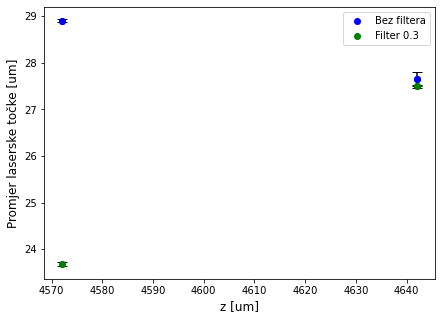

In [120]:
z2=[4642,4572]
s2=[27.49,23.68]
se2=[0.04,0.05]
z1=[4642,4572]
s1=[27.65,28.9]
se1=[0.16,0.03]

plt.figure(figsize=(7, 5))
plt.scatter(z1, s1, color='blue', label = 'Bez filtera')
y_error1 =[se1, se1] 
plt.errorbar(z1, s1,yerr = y_error1, fmt ='o', ecolor='black',capsize=5,color='blue')

plt.scatter(z2, s2, color='green', label = 'Filter 0.3')
y_error2 =[se2, se2] 
plt.errorbar(z2, s2,yerr = y_error2, fmt ='o', ecolor='black',capsize=5,color='green' )

plt.xlabel("z [um]", fontsize=12)
plt.ylabel("Promjer laserske točke [um]", fontsize=12)

plt.legend()
plt.show()

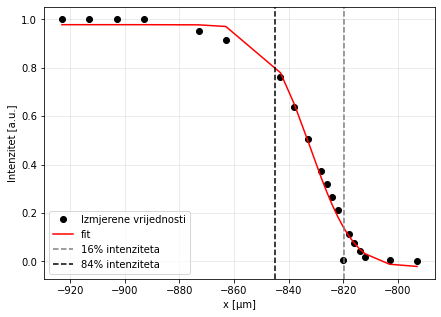

25.06 ± 0.10 um


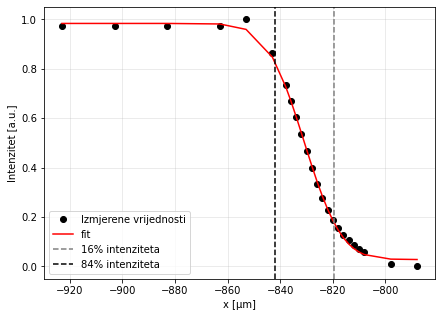

 22.41 ± 0.03 um


In [134]:
#leća
x0 = -923
y0 = -2395
z0 = 382.5
I0 = -0.00818
V = -0.3 
f = 10

x_G=[x0, x0+10,x0+20,x0+30,x0+50,x0+60,x0+80,x0+85,x0+90,x0+95,x0+97,x0+99,x0+101,x0+103,x0+105, x0+107,x0+109,x0+111,x0+120,x0+130]
I_G=[I0,I0,I0,I0,-0.00778,-0.00749,-0.00626,-0.00524,-0.00416,-0.00309,-0.00267,-0.00224,-0.00181,-0.000140,-0.001,-0.00068,-0.00042,-0.00024,-0.00013,-0.00008]

x_D=[x0, x0+20,x0+40,x0+60,x0+70,x0+80,x0+85,x0+87,x0+89,x0+91,x0+93,x0+95, x0+97,x0+99,x0+101,x0+103,x0+105,x0+107,x0+109,x0+111,x0+113,x0+115,x0+125,x0+135]
I_D=[I0,I0,I0,I0,-0.00841,-0.00730,-0.00621,-0.00569,-0.00515,-0.00459,-0.00403,-0.00347,-0.00294,-0.00247,-0.00207,-0.00175,-0.00147,-0.00124,-0.00106,-0.00091,-0.00078,-0.00066,-0.00026,-0.00019]

spot_size = spot_size_function(x_G, I_G)
print(f"{spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_D, I_D)
print(f" {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

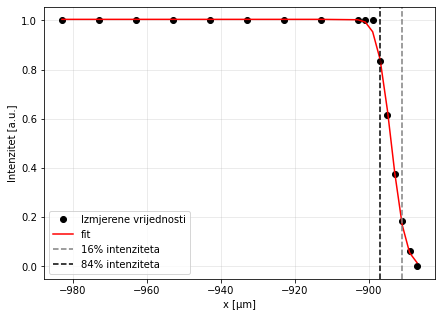

Spot size za z=-200 um: 6.07 ± 0.05 um


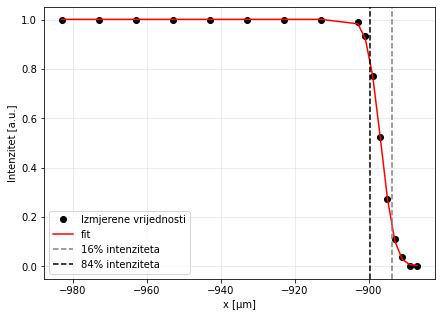

Spot size za z=-195, s filterom 0.3: 5.89 ± 0.02 um


In [141]:
x0 = -983
y0 = -2745
z01 = -195
z02 = -200.8
I0_z1 = -0.00109
I0_z2 = -0.00109
V = -0.3 
f = 10

x_z1=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+82,x0+84,x0+86,x0+88,x0+90,x0+92,x0+94,x0+96]
I_z1=[I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,I0_z1,-0.00091,-0.00067,-0.00041,-0.0002,-0.00007,0 ]

x_z2=[x0,x0+10,x0+20,x0+30,x0+40,x0+50,x0+60,x0+70,x0+80,x0+82,x0+84,x0+86,x0+88,x0+90,x0+92,x0+94,x0+96]
I_z2=[I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,I0_z2,-0.00108,-0.00102,-0.00084,-0.00057,-0.0003,-0.00012,-0.00004,0,0]

spot_size = spot_size_function(x_z1, I_z1)
print(f"Spot size za z=-200 um: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

spot_size = spot_size_function(x_z2, I_z2)
print(f"Spot size za z=-195, s filterom 0.3: {spot_size[0]:.2f} ± {spot_size[1]:.2f} um")

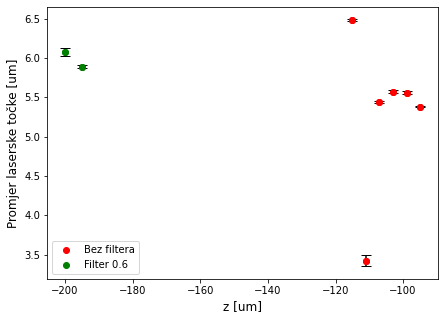

In [146]:
z2=[-200,-195]
s2=[6.07, 5.89]
se2=[0.05, 0.02]
z1=[-95,-99,-103, -107, -111, -115]
s1=[5.38,5.56,5.57,5.44, 3.42, 6.48]
se1=[0.01,0.02,0.02, 0.01, 0.07, 0.01]

plt.figure(figsize=(7, 5))
plt.scatter(z1, s1, color='red', label = 'Bez filtera')
y_error1 =[se1, se1] 
plt.errorbar(z1, s1,yerr = y_error1, fmt ='o', ecolor='black',capsize=5,color='red')

plt.scatter(z2, s2, color='green', label = 'Filter 0.6')
y_error2 =[se2, se2] 
plt.errorbar(z2, s2,yerr = y_error2, fmt ='o', ecolor='black',capsize=5,color='green' )


plt.xlabel("z [um]", fontsize=12)
plt.ylabel("Promjer laserske točke [um]", fontsize=12)

plt.legend(loc='lower left')
plt.show()

